# Telco Customer Churn

This notebook uses real-world data from the Telco industry with the goal to effectively predict customer churn. 

Customer churn occurs when customers decide to end their subscriptions or services with the telecom company. The goal is to create logistic regression and random forest machine learning models that can forecast customer churn. By analysing historical customer data, these models will help us determine the likelihood of a customer either leaving the service (churning) or staying with it. This predictive capability is crucial for the telecom company to implement effective retention strategies

## Import Data

In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


## Load and Inspect Dataset

In [183]:
# Load Telco dataset
telco_df = pd.read_csv("Telco-Customer-Churn.csv", sep=",")

# Display the first ten rows of the dataset. 
telco_df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [184]:
# Output the names of the dataset's columns. 
telco_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [185]:
# Display the data types of each column. 
telco_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Preprocess Data

In [186]:
# Convert the “TotalCharges” column to the numeric data type.

telco_df["TotalCharges"] = pd.to_numeric(
    telco_df["TotalCharges"],
    errors="coerce"  # need to coerce because some entries might be empty/contain spaces
)

In [187]:
# Remove rows with missing values from the dataset.
telco_df = telco_df.dropna()

In [188]:
# Remove the “customerID” column from the dataset. 
telco_df = telco_df.drop(columns=['customerID'])

In [205]:
# Convert the “Churn” column to binary numeric values: replace “Yes” with 1 and “No” with 0. 
telco_df["Churn"] = telco_df["Churn"].replace({"Yes": 1, "No": 0})

In [190]:
# Convert all categorical variables into dummy variables using one-hot encoding. 
# Store the result in a new DataFrame called telecom_cust_dummies to keep telco_df unchanged 

teleco_encoded_df = pd.get_dummies(
    telco_df,
    drop_first=True  # first category dropped to prevent multicollinearity.
)

## Visualise Data

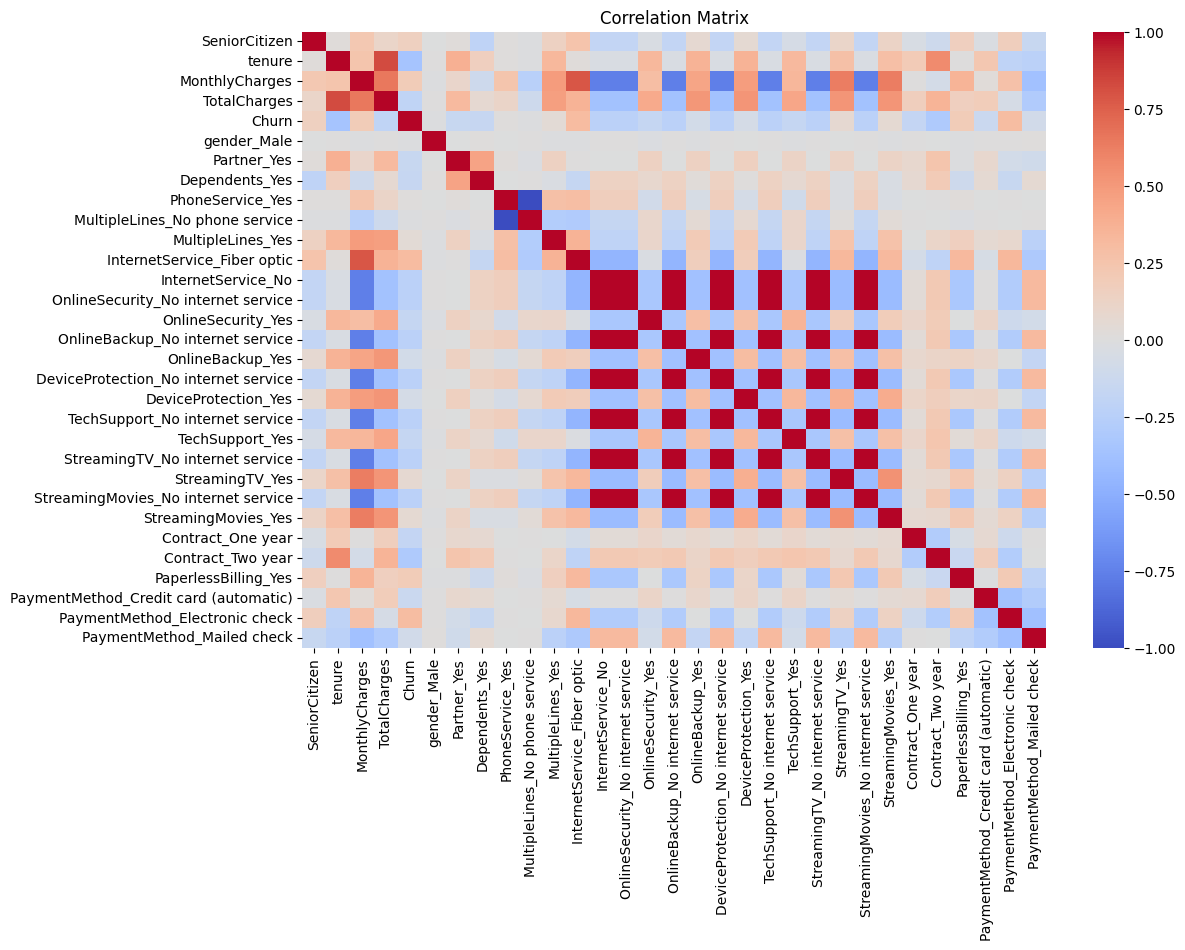

In [191]:
# Create a correlation plot to visualise the correlation between features and the target variable “Churn”. 
teleco_encoded_df.corr()["Churn"].sort_values() # need to use dummies df, not telco_df

corr = teleco_encoded_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The correlation heatmap shows that tenure and long-term contracts are negatively correlated with churn, indicating that customers who remain longer or commit to extended contracts are less likely to churn. In contrast, higher monthly charges and fiber optic internet service exhibit a positive correlation with churn, suggesting an increased likelihood of customer shurn.

The strong correlation block among internet service–related variables is a result of one-hot encoding and reflects structural dependencies between features rather than independent relationships.

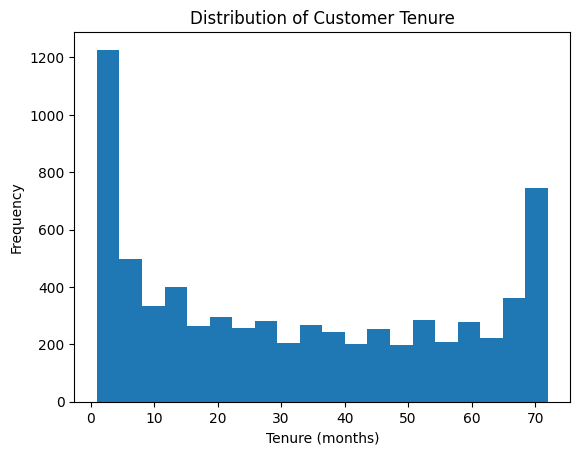

In [192]:
# Create a histogram of the “tenure” column. 

plt.hist(telco_df["tenure"], bins=20)
plt.xlabel("Tenure (months)")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Tenure")
plt.show()

The histogram shows that customer tenure is not evenly distributed. A large proportion of customers have very short tenures, indicating early churn, while a second concentration of customers appears at high tenure values, representing long-term loyal customers. This suggests that customers who remain beyond the initial period are more likely to stay with the company for extended durations.

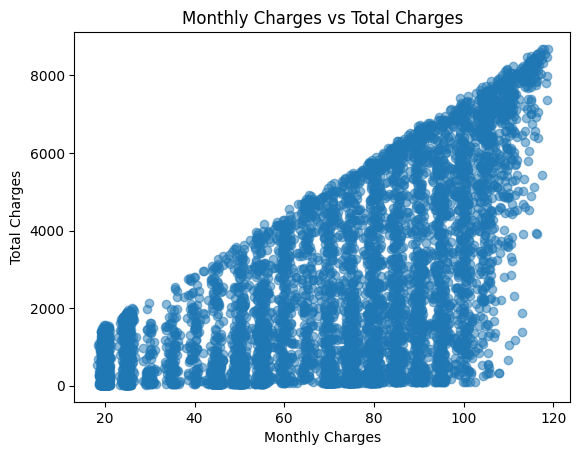

In [193]:
# Create a scatter plot of “MonthlyCharges” vs. “TotalCharges”.

plt.scatter(
    telco_df["MonthlyCharges"],
    telco_df["TotalCharges"],
    alpha=0.5
)
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.title("Monthly Charges vs Total Charges")
plt.show()

The scatter plot reveals a strong positive relationship between MonthlyCharges and TotalCharges, with total charges increasing as monthly charges rise. The triangular distribution reflects variation in customer tenure, as customers with longer service durations accumulate higher total charges. Vertical clustering at specific monthly charge values suggests the presence of fixed pricing plans, while instances of high monthly charges combined with low total charges likely correspond to new or early-churn customers.

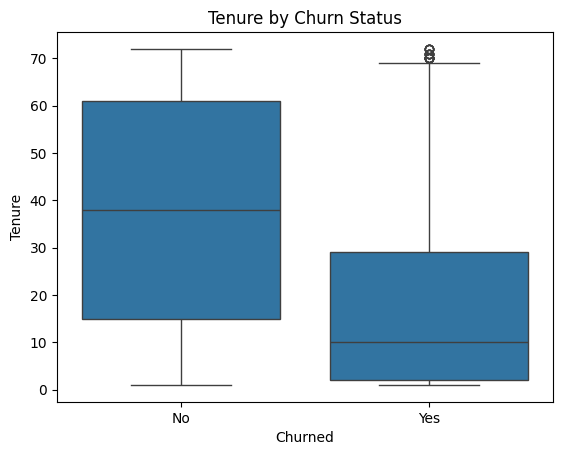

In [194]:
# Create a box plot to compare “tenure” for churned and non-churned customers.
telco_df["ChurnLabel"] = telco_df["Churn"].map({0: "No", 1: "Yes"})

sns.boxplot(
    x="ChurnLabel",
    y="tenure",
    data=telco_df
)
plt.title("Tenure by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Tenure")
plt.show()

As shown in the box plot, customers with shorter tenure are more likely to churn.

## Prepare data for ML training 

In [195]:
# Seperate X and y using dummy dataframe 
X = teleco_encoded_df.drop('Churn', axis=1)
y = teleco_encoded_df['Churn']


In [196]:
# Split the dataset into training and test sets (X_train; X_test; y_train; y_test) with a test size of 25%. 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,  # test size of 25%.
    random_state=42,  # to ensure reproducibility of the train–test split
    stratify=y  # both sets same churn ratio as original data
)

# Sanity Check
print("Training data:",X_train.shape, y_train.shape)
print("Test data:",X_test.shape, y_test.shape)

Training data: (5274, 30) (5274,)
Test data: (1758, 30) (1758,)


In [197]:
# Scale all the variables to a range of 0 to 1 using min-max scaling. 

# Create the scaler
scaler = MinMaxScaler()

# Fit and transform on training data 
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)  # not fitted to prevent data leakage

## Logistic regression model 

In [198]:
# Create the model
logreg = LogisticRegression()

# Fit the model to the training set
logreg.fit(X_train_scaled, y_train)  # use scaled data for logistic regression

# Make predictions on the test set
predictions = logreg.predict(X_test_scaled)

# Test and print accuracy
accuracy_check = accuracy_score(y_test, predictions)
print("Accuracy Score for Logistic Model:", accuracy_check)

Accuracy Score for Logistic Model: 0.8060295790671217


The accuracy score indicates that the logistic regression model achieved an accuracy of approximately 80%, indicating moderate overall performance.

## Random forest model 

In [199]:
# Create model with spesific hyperparameters
rf_model = RandomForestClassifier(
    n_estimators=2000,
    oob_score=True,
    max_features="sqrt",  # actually the default 
    max_leaf_nodes=50,
    bootstrap=True,  # also default setting 
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)  # not necessary to use scaled dataframe

# Prediction
preds = rf_model.predict(X_test)

# Test and print accuracy
accuracy_check_rf = accuracy_score(y_test, preds)
print("Accuracy Score for Random Forest Model:", accuracy_check_rf)

Accuracy Score for Random Forest Model: 0.7918088737201365


In [200]:
# Get OOB error estimation
oob_error = 1 - rf_model.oob_score_
print("OOB Error:", oob_error)

OOB Error: 0.2007963594994312


The OOB error estimation indicates that roughly 20% of the training samples are misclassified by the out-of-bag predictions. This indicates a moderate performance and the model might benifit from tuning. 

## Enhanced model evaluation 

### Confusion Matrix for the Logistic Model

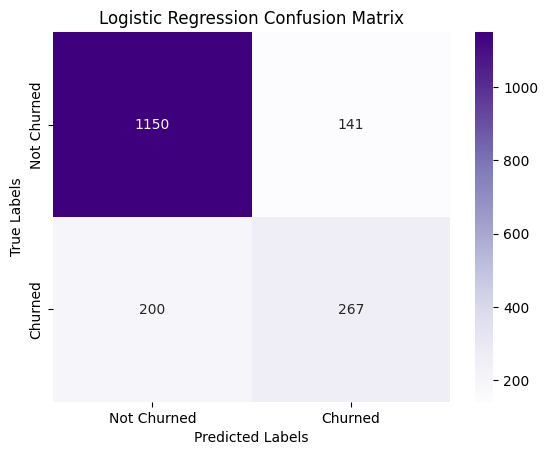

In [201]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)

# Define class labels
class_names = ['Not Churned', 'Churned']

# Plot the heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Confusion Matrix for the Random Forest Model

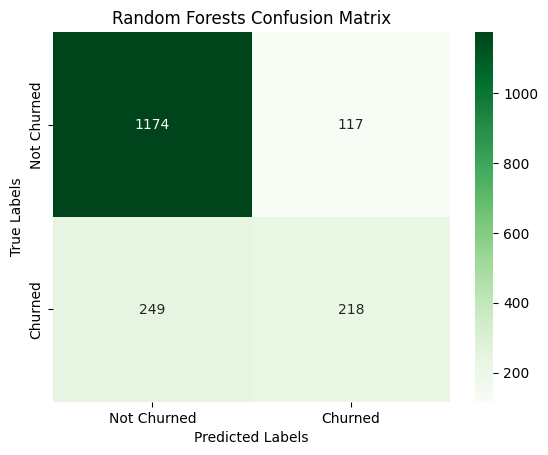

In [202]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, preds)

# Define class labels
class_names = ['Not Churned', 'Churned']

# Plot the heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Random Forests Confusion Matrix")
plt.show()

 If our goal with this analysis is to find ways to prevent customer churn, the point of interest is where the model missed customers who churned. This is to say that the model predicted they stay customers but in fact they churned. The logistic regression missed 200, while the random forest model missed 249. In this sense the logistic regression performs better. The confusion matrix also reveals that logistic regression correctly identifies more churners (higher recall), but may produce slightly more false positives.
 However, the random forest performed better at accurately labelling customers who did not churn. 

### Precision and Recall Scores

In [203]:
# Compute the precision and recall scores for the Logistic model
precision_check = precision_score(y_test, predictions, average='macro')
recall_check = recall_score(y_test, predictions, average='macro')
f1_check = f1_score(y_test, predictions, average='macro')

print("Precision Score for Logistic Model:", precision_check)
print("Recall Score for Logistic Model:", recall_check)
print("F1 Score for Logistic Model:", f1_check)


Precision Score for Logistic Model: 0.7531318082788672
Recall Score for Logistic Model: 0.7312584073233073
F1 Score for Logistic Model: 0.7405839779304376


In [204]:
# Compute the precision and recall scores for the Random Forest model
precision_check_rf = precision_score(y_test, preds, average='macro')
recall_check_rf = recall_score(y_test, preds, average='macro')
f1_check_rf = f1_score(y_test, preds, average='macro')

print("Precision Score for Random Forest:", precision_check_rf)
print("Recall Score for Random Forest:", recall_check_rf)
print("F1 Score for Random Forest:", f1_check_rf)


Precision Score for Random Forest: 0.7378819185869667
Recall Score for Random Forest: 0.6880910006186794
F1 Score for Random Forest: 0.7043922985461917


For the scores I decided to use the per-class scores (averge=macro) because minority class (churn) performance is often important in churn predictions. 

I added the F1 Score because it balances the tradeoff between precision and recall. The F1 score for logistic regression is 74% and for random forest it is 70%. This concludes that logistic regression is the better option. 

## Summary

The confusion matrixes revealed that logistic regression missed 200, while the random forest model missed 249 of customers who churned. However, the random forest performed better at accurately labelling customers who did not churn. 

Both aspects must be taken into consideration when deciding which model to use. The choice will be dictated by the goal of the analysis. If the goal of the analysis is to identify customers who churn, logic regression is recommended. 

Logic regression is also recommended if the precision and recall scores are considered. Logic regression scored about 2% better in precision, 5 % better in recall about 4% better regarding the F1 score. 
